# Hệ thống đề xuất món ăn theo nguyên liệu

## Mục tiêu
Xây dựng hệ thống:
- Phân loại khẩu vị người dùng (biến appetite)
- Gợi ý món ăn dựa trên nguyên liệu đầu vào

## Bài toán
Input:
- Nguyên liệu người dùng nhập

Output:
- Nhóm khẩu vị (savory: đậm đà / sweet: món ngọt / low-sodium: ít muối)
- Danh sách món ăn phù hợp

## Hướng tiếp cận
- Xử lý văn bản nguyên liệu
- TF-IDF vectorization
- KNN: cosine similarity
- Hệ thống đề xuất kiểu Hybrid: similarity + overlap

In [1]:
import re
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils import resample

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except:
    WORDCLOUD_AVAILABLE = False

In [2]:
DATA_PATH = Path("/kaggle/input/datasets/shuyangli94/foodcom-recipes-with-search-terms-and-tags/recipes_w_search_terms.csv")
TARGET_PER_CLASS = 2000
TFIDF_MAX_FEATURES = 5000
K = 3

In [3]:
UNIT_PATTERNS = [
    r'\b\d+/\d+\b', r'\b\d+\b', r'\b\d+\.\d+\b',
    r'\b(tsp|tbsp|cup|grams|g|kg|oz|ml|l|lb|lbs)\b',
    r'\(.*?\)', r'[\d\-/]+'
]
UNIT_RE = re.compile("|".join(UNIT_PATTERNS), flags=re.IGNORECASE)

def clean_ingredient(text):
    text = str(text).lower()
    text = UNIT_RE.sub(" ", text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in ENGLISH_STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

In [4]:
def extract_appetite(search_text):
    if pd.isna(search_text):
        return None
    s = str(search_text).lower()

    if any(x in s for x in ['sweet', 'dessert', 'sugar', 'cake', 'chocolate']):
        return 'sweet'

    if any(x in s for x in ['savory', 'spicy', 'meat', 'umami', 'salty']):
        return 'savory'

    if any(x in s for x in ['low sodium', 'low-sodium', 'low salt', 'diet', 'healthy']):
        return 'low-sodium'

    return None

In [5]:
df = pd.read_csv(DATA_PATH)
print('Data Raw')
df.info()


df['clean_ingredients'] = df['ingredients'].fillna('').apply(clean_ingredient)
df['appetite'] = df['search_terms'].apply(extract_appetite)

df = df.dropna(subset=['appetite'])
df = df[df['clean_ingredients'].str.strip() != ""]

print("Class distribution (raw):")
print(df['appetite'].value_counts())

Data Raw
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494963 entries, 0 to 494962
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   id                   494963 non-null  int64 
 1   name                 494963 non-null  object
 2   description          485362 non-null  object
 3   ingredients          494963 non-null  object
 4   ingredients_raw_str  494963 non-null  object
 5   serving_size         494963 non-null  object
 6   servings             494963 non-null  int64 
 7   steps                494963 non-null  object
 8   tags                 494963 non-null  object
 9   search_terms         494963 non-null  object
dtypes: int64(2), object(8)
memory usage: 37.8+ MB
Class distribution (raw):
appetite
sweet         117160
low-sodium     96941
savory           145
Name: count, dtype: int64


In [6]:
balanced = []
for label in df['appetite'].unique():
    subset = df[df['appetite'] == label]
    if len(subset) > TARGET_PER_CLASS:
        subset = resample(subset, replace=False, n_samples=TARGET_PER_CLASS, random_state=42)
    else:
        subset = resample(subset, replace=True, n_samples=TARGET_PER_CLASS, random_state=42)
    balanced.append(subset)

df_bal = pd.concat(balanced)

print("\nBalanced distribution:")
print(df_bal['appetite'].value_counts())

# TF-IDF VECTOR
vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES)
X = vectorizer.fit_transform(df_bal['clean_ingredients'])

le = LabelEncoder()
y = le.fit_transform(df_bal['appetite'])


Balanced distribution:
appetite
sweet         2000
low-sodium    2000
savory        2000
Name: count, dtype: int64


In [7]:
# TRAIN MODEL
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model = KNeighborsClassifier(n_neighbors=K, metric='cosine', weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=3, weights='distance')


F1 Score: 0.8991874787535884

Classification Report:

              precision    recall  f1-score   support

  low-sodium       0.90      0.81      0.85       400
      savory       0.93      1.00      0.96       400
       sweet       0.88      0.90      0.89       400

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200



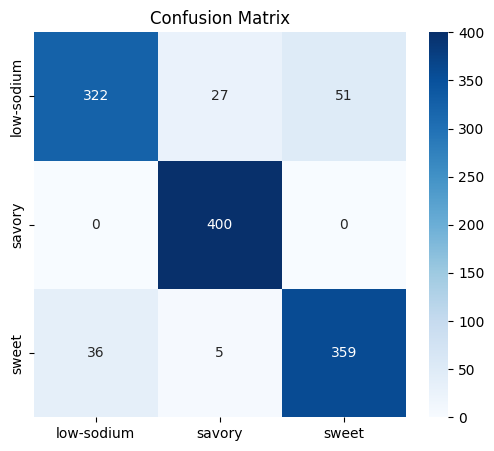

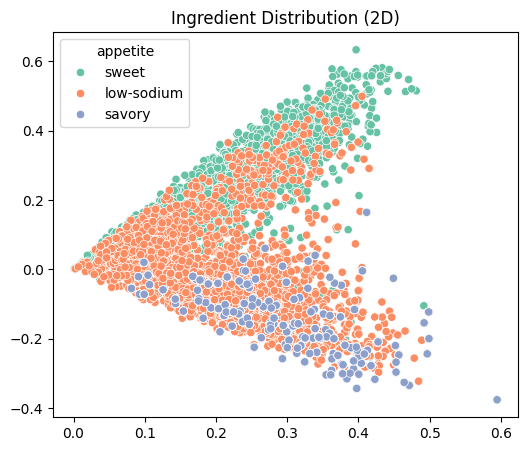

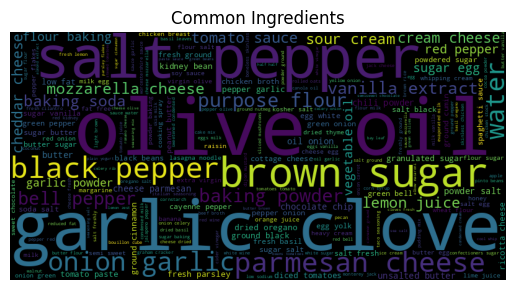

In [8]:
# ĐÁNH GIÁ - EVALUATION 

y_pred = model.predict(X_test)

print("\nF1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.show()


svd = TruncatedSVD(n_components=2)
X_2d = svd.fit_transform(X)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=df_bal['appetite'], palette='Set2')
plt.title("Ingredient Distribution (2D)")
plt.show()

if WORDCLOUD_AVAILABLE:
    text_blob = " ".join(df_bal['clean_ingredients'])
    wc = WordCloud(width=800, height=400).generate(text_blob)
    plt.imshow(wc)
    plt.axis("off")
    plt.title("Common Ingredients")
    plt.show()

In [9]:
# RECOMMENDER
def recommend(user_input, top_k=5):
    cleaned = clean_ingredient(user_input)
    user_vec = vectorizer.transform([cleaned])

    cos_sim = cosine_similarity(user_vec, X).flatten()

    user_tokens = set(cleaned.split())

    def overlap(idx):
        recipe_tokens = set(df_bal.iloc[idx]['clean_ingredients'].split())
        return len(user_tokens & recipe_tokens) / max(len(user_tokens), 1)

    overlap_scores = np.array([overlap(i) for i in range(len(df_bal))])

    hybrid = 0.7 * cos_sim + 0.3 * overlap_scores

    top_idx = np.argsort(hybrid)[-top_k:][::-1]

    return df_bal.iloc[top_idx][['name', 'appetite', 'ingredients']]

/tmp/ipykernel_17/932638137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_bal['appetite'], palette='Set2')


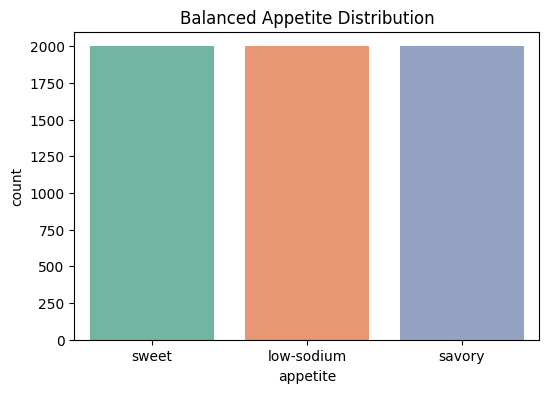

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_bal['appetite'], palette='Set2')
plt.title("Balanced Appetite Distribution")
plt.show()

In [11]:
# VÍ DỤ MOCKUP - TEST RECOMMENDER

print("\nSample Recommendation:")
print(recommend("chicken garlic butter"))


Sample Recommendation:
                                       name    appetite  \
366289                Country Style Chicken  low-sodium   
79500      O'charley's Chicken Harvest Soup  low-sodium   
9585    Saut&eacute;ed Lemon Chicken Strips  low-sodium   
160069       Curry Chicken Breast Casserole  low-sodium   
182694                      Chicken Pot Pie  low-sodium   

                                              ingredients  
366289  ['whole chicken', 'butter', 'flour', 'salt', '...  
79500   ['butter', 'flour', 'water', 'chicken base', '...  
9585    ['chicken tenderloins', 'salt and pepper', 've...  
160069  ['long-grain rice', 'chicken broth', 'chicken ...  
182694  ['potatoes', 'garlic', 'celery', 'onion', 'but...  


In [12]:
print(recommend("flour banana chocolate egg"))

                                               name appetite  \
455113                    Banana Nut Fudge Brownies    sweet   
233065  Banana Peanut Butter Chocolate Chip Cookies    sweet   
179947        Banana-Oatmeal Chocolate Chip Cookies    sweet   
191826                Healthy Chocolatechip Cookies    sweet   
77599                                 Banana Crepes    sweet   

                                              ingredients  
455113  ['all-purpose flour', 'vanilla', 'sugar', 'bak...  
233065  ['all-purpose flour', 'ground flax seeds', 'ba...  
179947  ['banana', 'brown sugar', 'butter', 'granulate...  
191826  ['whole wheat flour', 'baking soda', 'salt', '...  
77599   ['eggs', 'milk', 'oil', 'vanilla', 'banana', '...  


In [13]:
print(recommend("pork salt carrot celery onion noodles rice beef milk water beans chillies garlic"))

                         name    appetite  \
147854         Hamburger Soup  low-sodium   
391637        Minestrone Soup  low-sodium   
430441       Green Chile Stew  low-sodium   
349962  Pork Chops Florentine  low-sodium   
83499     Japanese Curry Rice  low-sodium   

                                              ingredients  
147854  ['ground beef', 'onion', 'garlic clove', 'cond...  
391637  ['onion', 'zucchini', 'butter', 'carrot', 'cel...  
430441  ['lean pork', 'lean beef', 'vegetable oil', 'o...  
349962  ['pork chops', 'salt', 'pepper', 'water', 'spi...  
83499   ['cooked japanese-style rice', 'potatoes', 'ca...  
